# Task 01 - Hierarchical Clustering In Non-Euclidean Spaces

This notebook is self-contained and portable across local Jupyter environments and Google Colab.

## Rubric Mapping

- Generate about 10,000 alphabetical strings with lengths in `[32, 64]`: `StringDatasetBuilder`
- Apply 4-shingles and save `index, string, shingles`: `Shingler` plus CSV export
- Use Jaccard distance: `jaccard_distance`
- Distributed computation: Spark-based dataset generation and shingle extraction
- Agglomerative clustering with a merge threshold `t`: `AgglomerativeClusteringRunner`
- Approach 2 from the lecture: represent each cluster as its collection of strings and merge by minimum pairwise inter-cluster Jaccard distance
- Stop on abnormal diameter jump: `DiameterJumpDetector`
- OOP and compact code: focused classes
- Experimental tracking and line chart for `global_avg_dist`: metrics history section
- 3D t-SNE visualization: final visualization section


## 1. Dependency Setup


In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "pyspark": "pyspark",
}

def ensure_packages(required_packages):
    missing = []
    for package_name, module_name in required_packages.items():
        try:
            importlib.import_module(module_name)
        except ImportError:
            missing.append(package_name)
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure_packages(REQUIRED_PACKAGES)


## 2. Imports, Paths, And Configuration


In [2]:
import heapq
import math
import random
import statistics
import string
import sys
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE

plt.style.use("seaborn-v0_8-whitegrid")

IN_COLAB = "google.colab" in sys.modules
OUTPUT_DIR = Path.cwd()
DATASET_PATH = OUTPUT_DIR / "task01_strings.csv"
METRICS_PATH = OUTPUT_DIR / "task01_metrics.csv"
LINE_CHART_PATH = OUTPUT_DIR / "task01_global_avg_dist.png"
TSNE_PATH = OUTPUT_DIR / "task01_tsne_3d.png"

@dataclass
class Task01Config:
    total_strings: int = 10000
    prototype_count: int = 25
    min_length: int = 32
    max_length: int = 64
    min_shared_shingles: int = 3
    top_candidate_neighbors: int = 30
    heap_neighbors: int = 8
    max_sample_per_cluster: int = 20
    threshold_quantile: float = 0.90
    threshold_padding: float = 0.05
    max_threshold: float = 0.85
    jump_warmup: int = 30
    jump_window: int = 20
    jump_factor: float = 1.75
    jump_delta: float = 0.10
    tsne_sample_size: int = 2500
    random_seed: int = 42
    spark_partitions: int = 16

CONFIG = Task01Config()
print(CONFIG)


Task01Config(total_strings=10000, prototype_count=25, min_length=32, max_length=64, min_shared_shingles=3, top_candidate_neighbors=30, heap_neighbors=8, max_sample_per_cluster=20, threshold_quantile=0.9, threshold_padding=0.05, max_threshold=0.85, jump_warmup=30, jump_window=20, jump_factor=1.75, jump_delta=0.1, tsne_sample_size=2500, random_seed=42, spark_partitions=16)


## 3. Spark Session


In [3]:
def build_spark(app_name: str) -> SparkSession:
    builder = (
        SparkSession.builder.master("local[*]")
        .appName(app_name)
        .config("spark.sql.shuffle.partitions", str(CONFIG.spark_partitions))
        .config("spark.default.parallelism", str(CONFIG.spark_partitions))
    )
    spark_session = builder.getOrCreate()
    spark_session.sparkContext.setLogLevel("ERROR")
    return spark_session

spark = build_spark("MMDS-Task01")


## 4. Dataset Generation And Shingling Classes


In [4]:
class StringDatasetBuilder:
    def __init__(self, config: Task01Config):
        self.config = config
        self.prototype_rng = random.Random(config.random_seed)
        self.alphabet = string.ascii_lowercase
        self.prototype_strings = [
            self._random_string(self.prototype_rng.randint(40, 56), self.prototype_rng)
            for _ in range(config.prototype_count)
        ]

    def _random_string(self, length: int, rng: random.Random) -> str:
        return "".join(rng.choice(self.alphabet) for _ in range(length))

    def _mutate_string(self, base: str, row_seed: int) -> str:
        rng = random.Random(row_seed)
        chars = list(base)
        edit_count = rng.randint(4, 9)
        for _ in range(edit_count):
            op = rng.choice(["sub", "ins", "del"])
            if op == "sub" and chars:
                pos = rng.randrange(len(chars))
                chars[pos] = rng.choice(self.alphabet)
            elif op == "ins" and len(chars) < self.config.max_length:
                pos = rng.randrange(len(chars) + 1)
                chars.insert(pos, rng.choice(self.alphabet))
            elif op == "del" and len(chars) > self.config.min_length:
                pos = rng.randrange(len(chars))
                chars.pop(pos)
        while len(chars) < self.config.min_length:
            chars.insert(rng.randrange(len(chars) + 1), rng.choice(self.alphabet))
        while len(chars) > self.config.max_length:
            chars.pop(rng.randrange(len(chars)))
        mixed = "".join(chars)
        if rng.random() < 0.5:
            mixed = "".join(ch.upper() if rng.random() < 0.30 else ch for ch in mixed)
        return mixed

    def generate(self, spark_session: SparkSession):
        config = self.config
        prototype_strings = list(self.prototype_strings)

        def build_row(index_value: int):
            prototype_id = index_value % config.prototype_count
            row_seed = config.random_seed + index_value * 37
            generated_string = self._mutate_string(prototype_strings[prototype_id], row_seed)
            return (index_value, prototype_id, generated_string)

        rows = (
            spark_session.sparkContext.parallelize(range(config.total_strings), config.spark_partitions)
            .map(build_row)
        )
        schema = T.StructType(
            [
                T.StructField("index", T.IntegerType(), False),
                T.StructField("prototype_id", T.IntegerType(), False),
                T.StructField("string", T.StringType(), False),
            ]
        )
        dataset_df = spark_session.createDataFrame(rows, schema=schema)

        shingle_udf = F.udf(
            lambda text: sorted({text.lower()[i : i + 4] for i in range(len(text) - 3)}),
            T.ArrayType(T.StringType()),
        )
        dataset_df = dataset_df.withColumn("shingles", shingle_udf("string")).cache()
        return dataset_df


class Shingler:
    @staticmethod
    def jaccard_distance(left, right):
        intersection_size = len(left & right)
        union_size = len(left | right)
        return 1.0 - (intersection_size / union_size if union_size else 0.0)


## 5. Candidate Index And Diameter Jump Detector


In [5]:
class OverlapCandidateIndex:
    def __init__(self, shingle_map, min_shared_shingles, top_candidate_neighbors):
        self.shingle_map = shingle_map
        self.min_shared_shingles = min_shared_shingles
        self.top_candidate_neighbors = top_candidate_neighbors
        self.inverted_index = defaultdict(list)
        self.neighbor_map = {}

    def build(self):
        for item_id, shingles in self.shingle_map.items():
            for shingle in shingles:
                self.inverted_index[shingle].append(item_id)

        nearest_distances = []
        for item_id, shingles in self.shingle_map.items():
            overlap_counter = Counter()
            for shingle in shingles:
                for neighbor_id in self.inverted_index[shingle]:
                    if neighbor_id != item_id:
                        overlap_counter[neighbor_id] += 1

            candidate_ids = [
                neighbor_id
                for neighbor_id, overlap_count in overlap_counter.items()
                if overlap_count >= self.min_shared_shingles
            ]
            scored_candidates = sorted(
                (
                    Shingler.jaccard_distance(shingles, self.shingle_map[neighbor_id]),
                    neighbor_id,
                )
                for neighbor_id in candidate_ids
            )[: self.top_candidate_neighbors]
            self.neighbor_map[item_id] = scored_candidates
            if scored_candidates:
                nearest_distances.append(scored_candidates[0][0])

        return self.neighbor_map, nearest_distances


class DiameterJumpDetector:
    def __init__(self, warmup, window, jump_factor, jump_delta):
        self.warmup = warmup
        self.window = window
        self.jump_factor = jump_factor
        self.jump_delta = jump_delta
        self.history = []

    def should_stop(self, candidate_diameter):
        if len(self.history) < self.warmup:
            return False
        recent = self.history[-self.window :]
        return (
            candidate_diameter > statistics.median(recent) * self.jump_factor
            and candidate_diameter - recent[-1] > self.jump_delta
        )

    def observe(self, diameter_value):
        self.history.append(diameter_value)


## 6. Cluster Statistics Model


In [6]:
class Cluster:
    def __init__(self, cluster_id, member_ids, shingle_map, rng, max_sample_size):
        self.cluster_id = cluster_id
        self.member_ids = sorted(member_ids)
        self.size = len(self.member_ids)
        self.stat_ids = self._sample_member_ids(rng, max_sample_size)
        self.avg_dist, self.diameter = self._compute_stats(shingle_map)

    def _sample_member_ids(self, rng, max_sample_size):
        if len(self.member_ids) <= max_sample_size:
            return list(self.member_ids)
        return sorted(rng.sample(self.member_ids, max_sample_size))

    def _compute_stats(self, shingle_map):
        if len(self.stat_ids) == 1:
            return 0.0, 0.0

        pair_distances = []
        for offset, left_id in enumerate(self.stat_ids):
            left_shingles = shingle_map[left_id]
            for right_id in self.stat_ids[offset + 1 :]:
                pair_distances.append(
                    Shingler.jaccard_distance(left_shingles, shingle_map[right_id])
                )

        avg_dist = float(np.mean(pair_distances))
        diameter = float(np.max(pair_distances))
        return avg_dist, diameter


## 7. Agglomerative Clustering Runner


In [7]:
class AgglomerativeClusteringRunner:
    def __init__(self, config, shingle_map, neighbor_map, threshold):
        self.config = config
        self.shingle_map = shingle_map
        self.neighbor_map = neighbor_map
        self.threshold = threshold
        self.rng = random.Random(config.random_seed)
        self.jump_detector = DiameterJumpDetector(
            warmup=config.jump_warmup,
            window=config.jump_window,
            jump_factor=config.jump_factor,
            jump_delta=config.jump_delta,
        )

    def cluster_distance(self, left_cluster, right_cluster):
        best_distance = 1.0
        for left_id in left_cluster.member_ids:
            left_shingles = self.shingle_map[left_id]
            for right_id in right_cluster.member_ids:
                distance_value = Shingler.jaccard_distance(
                    left_shingles,
                    self.shingle_map[right_id],
                )
                if distance_value < best_distance:
                    best_distance = distance_value
                    if best_distance == 0.0:
                        return 0.0
        return best_distance

    def candidate_cluster_ids(self, cluster, item_to_cluster, clusters):
        candidate_ids = set()
        for member_id in cluster.member_ids:
            for _, neighbor_id in self.neighbor_map.get(member_id, []):
                candidate_cluster_id = item_to_cluster[neighbor_id]
                if candidate_cluster_id != cluster.cluster_id and candidate_cluster_id in clusters:
                    candidate_ids.add(candidate_cluster_id)
        return candidate_ids

    def push_candidate_edges(self, cluster, item_to_cluster, clusters, distance_heap):
        for candidate_cluster_id in self.candidate_cluster_ids(cluster, item_to_cluster, clusters):
            candidate_cluster = clusters[candidate_cluster_id]
            candidate_distance = self.cluster_distance(cluster, candidate_cluster)
            if candidate_distance <= min(0.95, self.threshold + 0.08):
                heapq.heappush(
                    distance_heap,
                    (
                        candidate_distance,
                        min(cluster.cluster_id, candidate_cluster_id),
                        max(cluster.cluster_id, candidate_cluster_id),
                    ),
                )

    def run(self):
        clusters = {
            item_id: Cluster(
                cluster_id=item_id,
                member_ids=[item_id],
                shingle_map=self.shingle_map,
                rng=self.rng,
                max_sample_size=self.config.max_sample_per_cluster,
            )
            for item_id in self.shingle_map
        }
        item_to_cluster = {item_id: item_id for item_id in self.shingle_map}
        distance_heap = []
        for item_id, neighbor_list in self.neighbor_map.items():
            for distance_value, neighbor_id in neighbor_list[: self.config.heap_neighbors]:
                distance_heap.append((distance_value, min(item_id, neighbor_id), max(item_id, neighbor_id)))
        heapq.heapify(distance_heap)

        next_cluster_id = len(clusters)
        current_avg_sum = sum(cluster.avg_dist for cluster in clusters.values())
        history = []

        while distance_heap:
            candidate_distance, left_cluster_id, right_cluster_id = heapq.heappop(distance_heap)
            if left_cluster_id not in clusters or right_cluster_id not in clusters:
                continue
            if left_cluster_id == right_cluster_id:
                continue
            if candidate_distance > self.threshold:
                continue

            left_cluster = clusters[left_cluster_id]
            right_cluster = clusters[right_cluster_id]
            exact_distance = self.cluster_distance(left_cluster, right_cluster)
            if exact_distance > self.threshold:
                continue

            merged_members = left_cluster.member_ids + right_cluster.member_ids
            merged_cluster = Cluster(
                cluster_id=next_cluster_id,
                member_ids=merged_members,
                shingle_map=self.shingle_map,
                rng=self.rng,
                max_sample_size=self.config.max_sample_per_cluster,
            )
            if self.jump_detector.should_stop(merged_cluster.diameter):
                print(
                    f"Stopping before merge {next_cluster_id}: "
                    f"diameter jump detected ({merged_cluster.diameter:.4f})."
                )
                break

            current_avg_sum += merged_cluster.avg_dist - left_cluster.avg_dist - right_cluster.avg_dist
            del clusters[left_cluster_id]
            del clusters[right_cluster_id]
            clusters[next_cluster_id] = merged_cluster

            for member_id in merged_members:
                item_to_cluster[member_id] = next_cluster_id

            self.push_candidate_edges(merged_cluster, item_to_cluster, clusters, distance_heap)

            self.jump_detector.observe(merged_cluster.diameter)
            history.append(
                {
                    "step": len(history) + 1,
                    "active_clusters": len(clusters),
                    "merge_distance": exact_distance,
                    "merged_cluster_size": merged_cluster.size,
                    "merged_cluster_diameter": merged_cluster.diameter,
                    "global_avg_dist": current_avg_sum / len(clusters),
                }
            )
            next_cluster_id += 1

        return clusters, item_to_cluster, pd.DataFrame(history)


## 8. Generate Strings, Save CSV, And Estimate Threshold


In [8]:
dataset_builder = StringDatasetBuilder(CONFIG)
dataset_df = dataset_builder.generate(spark)

dataset_count = dataset_df.count()
assert dataset_count == CONFIG.total_strings, dataset_count
length_check = dataset_df.select(F.length("string").alias("length")).agg(F.min("length"), F.max("length")).collect()[0]
print("Generated rows:", dataset_count)
print("String length range:", (length_check[0], length_check[1]))

export_pdf = dataset_df.select("index", "string", "shingles").orderBy("index").toPandas()
export_pdf["shingles"] = export_pdf["shingles"].apply(lambda values: "|".join(values))
export_pdf.to_csv(DATASET_PATH, index=False)
print("Saved dataset to", DATASET_PATH)
assert DATASET_PATH.exists()

collected_rows = (
    dataset_df.select("index", "string", "shingles")
    .orderBy("index")
    .toPandas()
)
shingle_map = {
    int(row["index"]): frozenset(row["shingles"])
    for _, row in collected_rows.iterrows()
}
string_map = {
    int(row["index"]): row["string"]
    for _, row in collected_rows.iterrows()
}

candidate_index = OverlapCandidateIndex(
    shingle_map=shingle_map,
    min_shared_shingles=CONFIG.min_shared_shingles,
    top_candidate_neighbors=CONFIG.top_candidate_neighbors,
)
neighbor_map, nearest_distances = candidate_index.build()
threshold_t = min(
    CONFIG.max_threshold,
    float(np.quantile(nearest_distances, CONFIG.threshold_quantile)) + CONFIG.threshold_padding,
)
print("Estimated merge threshold t:", round(threshold_t, 4))


Generated rows: 10000
String length range: (34, 64)


Saved dataset to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task01\task01_strings.csv


Estimated merge threshold t: 0.7224


## 9. Run Agglomerative Clustering


In [9]:
clustering_runner = AgglomerativeClusteringRunner(
    config=CONFIG,
    shingle_map=shingle_map,
    neighbor_map=neighbor_map,
    threshold=threshold_t,
)
start_time = time.perf_counter()
final_clusters, item_to_cluster, metrics_df = clustering_runner.run()
elapsed = time.perf_counter() - start_time
print(f"Clustering completed in {elapsed:.2f} seconds.")

assert not metrics_df.empty, "The agglomerative process produced no metrics."
metrics_df.to_csv(METRICS_PATH, index=False)
print("Saved metrics to", METRICS_PATH)


Stopping before merge 10116: diameter jump detected (0.6901).
Clustering completed in 0.13 seconds.
Saved metrics to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task01\task01_metrics.csv


## 10. Inspect Raw Cluster Assignments


In [10]:
cluster_rows = []
for cluster_id, cluster in final_clusters.items():
    for member_id in cluster.member_ids:
        cluster_rows.append(
            {
                "index": member_id,
                "cluster_id": cluster_id,
                "cluster_size": cluster.size,
            }
        )
assignments_df = pd.DataFrame(cluster_rows).sort_values(["cluster_id", "index"]).reset_index(drop=True)
display(assignments_df.head(10))

raw_cluster_sizes = (
    assignments_df.groupby("cluster_id")["index"]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="size")
)
print("Raw cluster count after the stop rule:", len(raw_cluster_sizes))
display(raw_cluster_sizes.head(10))


,index,cluster_id,cluster_size
0,0,0,1
1,1,1,1
2,2,2,1
3,3,3,1
4,4,4,1
5,5,5,1
6,6,6,1
7,7,7,1
8,8,8,1
9,9,9,1


Raw cluster count after the stop rule: 9884


,cluster_id,size
0,10098,11
1,10105,8
2,10115,7
3,10100,7
4,10114,6
5,10097,6
6,10113,5
7,10077,5
8,10057,3
9,10051,3


## 11. Consolidate Clusters For Visualization


In [11]:
def cluster_to_cluster_min_distance(left_members, right_members, shingle_map):
    best_distance = 1.0
    for left_id in left_members:
        left_shingles = shingle_map[left_id]
        for right_id in right_members:
            distance_value = Shingler.jaccard_distance(left_shingles, shingle_map[right_id])
            if distance_value < best_distance:
                best_distance = distance_value
                if best_distance == 0.0:
                    return 0.0
    return best_distance

def consolidate_clusters(raw_clusters, shingle_map, anchor_count):
    ranked_clusters = sorted(raw_clusters.values(), key=lambda cluster: cluster.size, reverse=True)
    anchor_clusters = ranked_clusters[:anchor_count]
    consolidated_members = {
        anchor_cluster.cluster_id: list(anchor_cluster.member_ids)
        for anchor_cluster in anchor_clusters
    }
    for cluster in ranked_clusters[anchor_count:]:
        best_anchor_id, best_distance = min(
            [(
                anchor_cluster.cluster_id,
                cluster_to_cluster_min_distance(
                    cluster.member_ids,
                    anchor_cluster.member_ids,
                    shingle_map,
                ),
            )
            for anchor_cluster in anchor_clusters
            ],
            key=lambda item: item[1],
        )
        consolidated_members[best_anchor_id].extend(cluster.member_ids)
    return consolidated_members

consolidated_members = consolidate_clusters(
    raw_clusters=final_clusters,
    shingle_map=shingle_map,
    anchor_count=CONFIG.prototype_count,
)
consolidated_assignments = []
for consolidated_cluster_id, member_ids in consolidated_members.items():
    for member_id in member_ids:
        consolidated_assignments.append(
            {
                "index": member_id,
                "cluster_id": consolidated_cluster_id,
                "cluster_size": len(member_ids),
            }
        )
consolidated_assignments_df = (
    pd.DataFrame(consolidated_assignments)
    .sort_values(["cluster_id", "index"])
    .reset_index(drop=True)
)
cluster_sizes = (
    consolidated_assignments_df.groupby("cluster_id")["index"]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="size")
)
print("Consolidated cluster count used for visualization:", len(cluster_sizes))
display(cluster_sizes.head(10))


Consolidated cluster count used for visualization: 25


,cluster_id,size
0,10098,2440
1,10077,416
2,10100,412
3,10018,411
4,10084,410
5,10115,409
6,10004,408
7,10114,404
8,10048,403
9,10057,403


## 12. Plot Global Average Distance


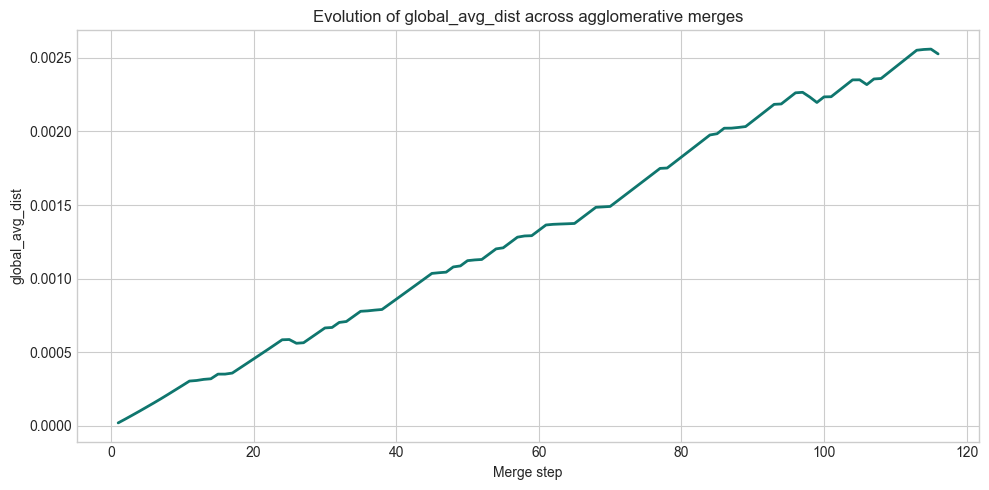

Saved line chart to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task01\task01_global_avg_dist.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics_df["step"], metrics_df["global_avg_dist"], color="#0f766e", linewidth=2)
ax.set_title("Evolution of global_avg_dist across agglomerative merges")
ax.set_xlabel("Merge step")
ax.set_ylabel("global_avg_dist")
fig.tight_layout()
fig.savefig(LINE_CHART_PATH, dpi=200, bbox_inches="tight")
plt.show()
print("Saved line chart to", LINE_CHART_PATH)
assert LINE_CHART_PATH.exists()


## 13. Prepare t-SNE Sample And Embedding


In [13]:
def stratified_sample(assignments_table, sample_size, random_seed):
    rng = random.Random(random_seed)
    sampled_indices = []
    grouped = assignments_table.groupby("cluster_id")["index"].apply(list)
    total_items = len(assignments_table)
    for _, member_ids in grouped.items():
        quota = max(1, int(round(sample_size * len(member_ids) / total_items)))
        if len(member_ids) <= quota:
            sampled_indices.extend(member_ids)
        else:
            sampled_indices.extend(rng.sample(member_ids, quota))
    if len(sampled_indices) > sample_size:
        sampled_indices = rng.sample(sampled_indices, sample_size)
    return sampled_indices

sampled_indices = stratified_sample(consolidated_assignments_df, CONFIG.tsne_sample_size, CONFIG.random_seed)
sampled_strings = [string_map[item_id] for item_id in sampled_indices]
consolidated_cluster_lookup = dict(
    zip(consolidated_assignments_df["index"], consolidated_assignments_df["cluster_id"])
)
sampled_clusters = [consolidated_cluster_lookup[item_id] for item_id in sampled_indices]

vectorizer = CountVectorizer(analyzer="char", ngram_range=(4, 4), lowercase=True, binary=True)
sparse_matrix = vectorizer.fit_transform(sampled_strings)
reduced_matrix = TruncatedSVD(n_components=25, random_state=CONFIG.random_seed).fit_transform(sparse_matrix)
perplexity_value = min(35, max(5, len(sampled_indices) // 50))
tsne_points = TSNE(
    n_components=3,
    random_state=CONFIG.random_seed,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity_value,
    max_iter=1000,
).fit_transform(reduced_matrix)


## 14. Plot 3D t-SNE And Summarize Results


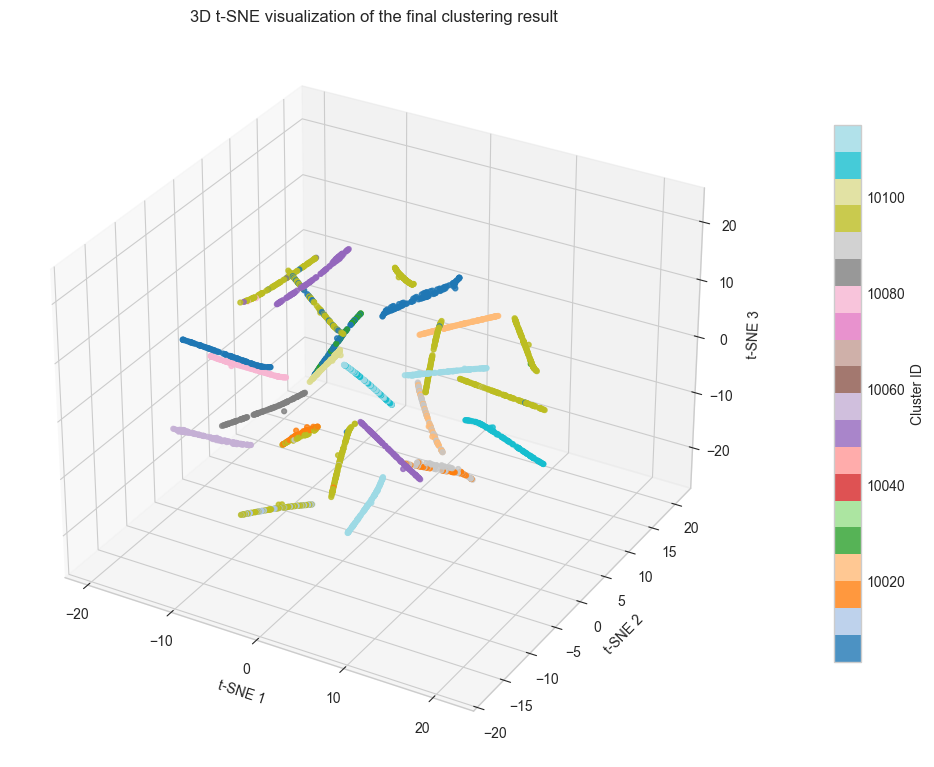

Saved t-SNE figure to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task01\task01_tsne_3d.png


,threshold_t,merge_steps,raw_clusters,visualization_clusters,largest_cluster,runtime_seconds
0,0.7224,116,9884,25,11,0.13


In [14]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    tsne_points[:, 0],
    tsne_points[:, 1],
    tsne_points[:, 2],
    c=sampled_clusters,
    cmap="tab20",
    s=12,
    alpha=0.8,
)
ax.set_title("3D t-SNE visualization of the final clustering result")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
fig.colorbar(scatter, ax=ax, shrink=0.7, pad=0.1, label="Cluster ID")
fig.tight_layout()
fig.savefig(TSNE_PATH, dpi=220, bbox_inches="tight")
plt.show()
print("Saved t-SNE figure to", TSNE_PATH)
assert TSNE_PATH.exists()

summary_row = {
    "threshold_t": round(threshold_t, 4),
    "merge_steps": int(metrics_df["step"].max()),
    "raw_clusters": int(raw_cluster_sizes.shape[0]),
    "visualization_clusters": int(cluster_sizes.shape[0]),
    "largest_cluster": int(raw_cluster_sizes["size"].max()),
    "runtime_seconds": round(elapsed, 2),
}
pd.DataFrame([summary_row])


## 15. Stop Spark


In [15]:
spark.stop()
